# Breast Cancer Wisconsin Classification

## 1. Problem definition

Can a logistic regression pipeline classify held-out samples as malignant or benign more effectively than a trivial baseline?

## 2. Imports and reproducibility

In [75]:
from sklearn.datasets import load_breast_cancer
from sklearn import set_config

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Dataset loading

In [58]:
data = load_breast_cancer(as_frame=True)
df = data.frame

## 4. Dataset inspection

In [31]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [36]:
df.info

<bound method DataFrame.info of      mean radius  mean texture  ...  worst fractal dimension  target
0          17.99         10.38  ...                  0.11890       0
1          20.57         17.77  ...                  0.08902       0
2          19.69         21.25  ...                  0.08758       0
3          11.42         20.38  ...                  0.17300       0
4          20.29         14.34  ...                  0.07678       0
..           ...           ...  ...                      ...     ...
564        21.56         22.39  ...                  0.07115       0
565        20.13         28.25  ...                  0.06637       0
566        16.60         28.08  ...                  0.07820       0
567        20.60         29.33  ...                  0.12400       0
568         7.76         24.54  ...                  0.07039       1

[569 rows x 31 columns]>

In [32]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='str')

In [34]:
df.dtypes.value_counts()

float64    30
int64       1
Name: count, dtype: int64

In [35]:
df.select_dtypes(include='int64').columns

Index(['target'], dtype='str')

In [39]:
df.isna().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [41]:
df.target.value_counts()

target
1    357
0    212
Name: count, dtype: int64

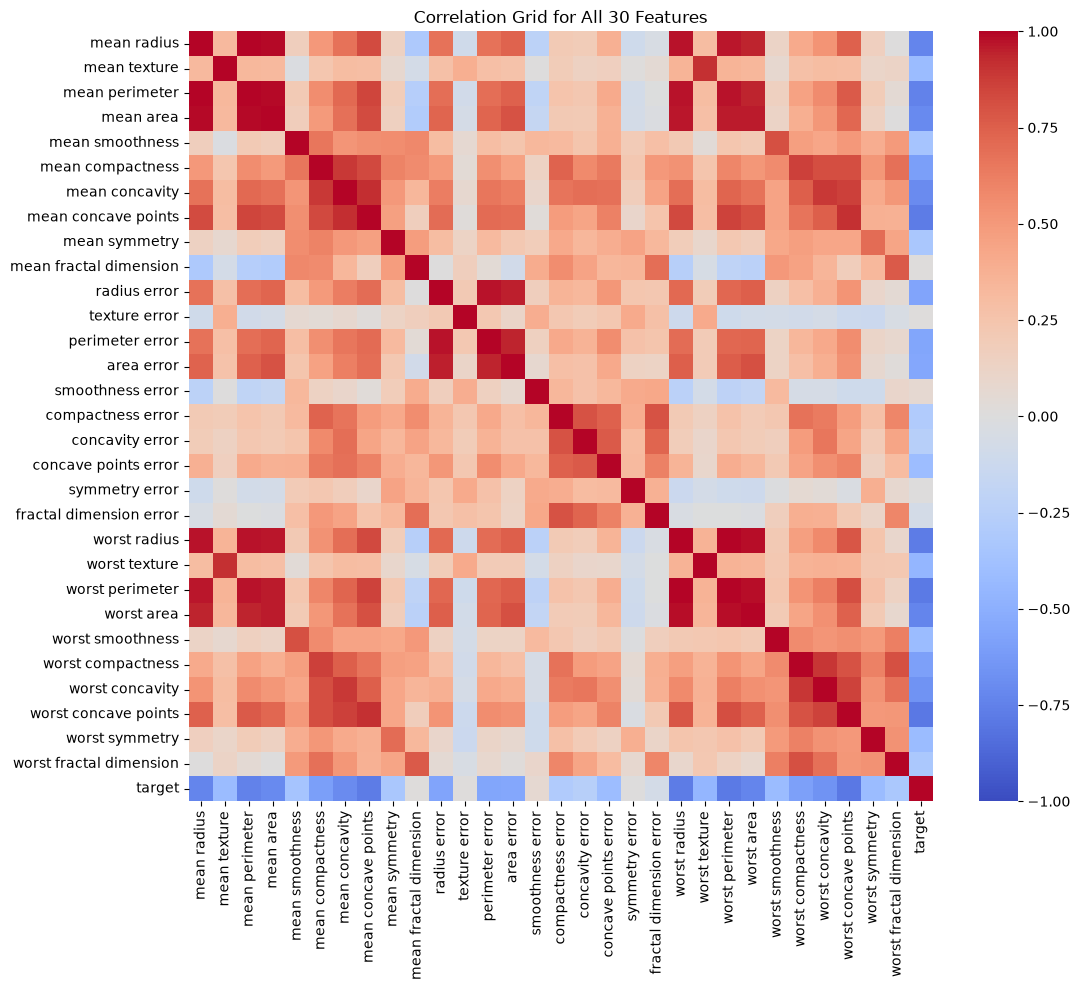

In [ ]:
# 1. Calculate the correlation numbers for all columns
correlation_matrix = df.corr()

# 2. Plot it as a heatmap (grid of colors)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Grid for All 30 Features")
plt.show()

In [50]:
duplicate_columns = ['mean radius', 'mean perimeter', 'radius error', 'perimeter error', 'worst radius', 'worst perimeter']

df_cleaned = df.drop(columns=duplicate_columns)

df_cleaned.info

<bound method DataFrame.info of      mean texture  mean area  ...  worst fractal dimension  target
0           10.38     1001.0  ...                  0.11890       0
1           17.77     1326.0  ...                  0.08902       0
2           21.25     1203.0  ...                  0.08758       0
3           20.38      386.1  ...                  0.17300       0
4           14.34     1297.0  ...                  0.07678       0
..            ...        ...  ...                      ...     ...
564         22.39     1479.0  ...                  0.07115       0
565         28.25     1261.0  ...                  0.06637       0
566         28.08      858.1  ...                  0.07820       0
567         29.33     1265.0  ...                  0.12400       0
568         24.54      181.0  ...                  0.07039       1

[569 rows x 25 columns]>

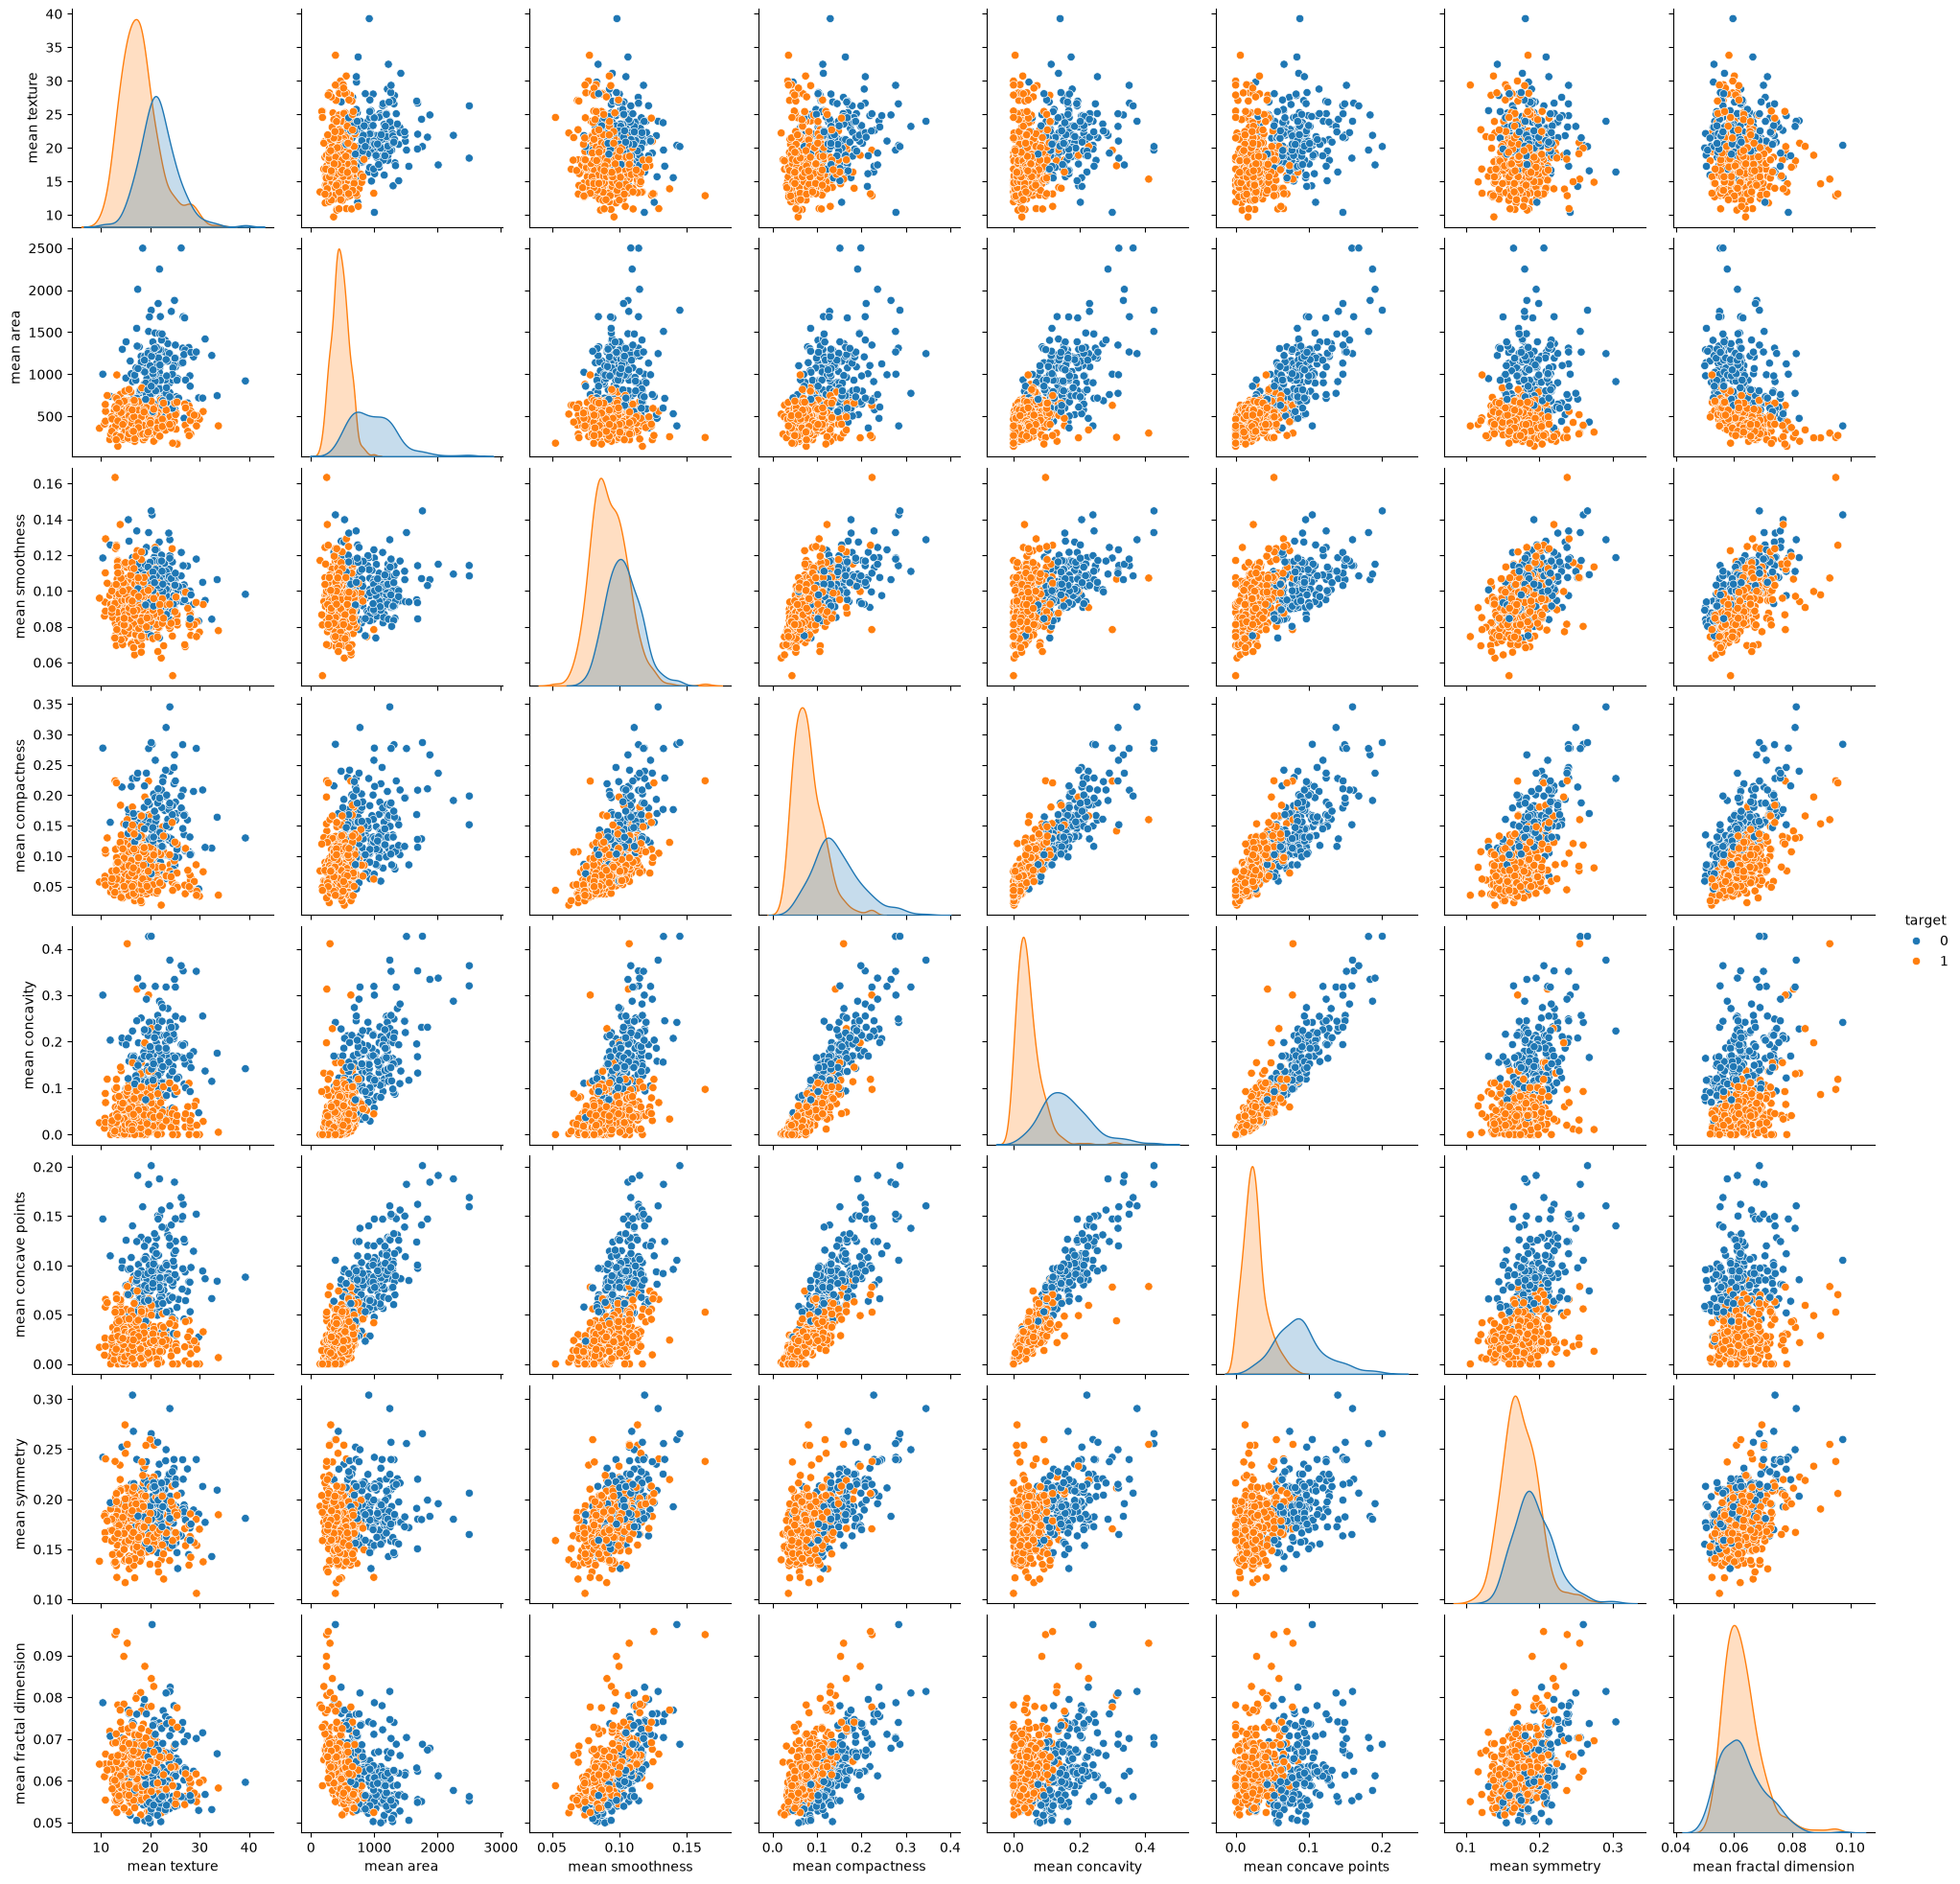

In [52]:
mean_features = [col for col in df_cleaned.columns if 'mean' in col] + ['target']
error_features = [col for col in df_cleaned.columns if 'error' in col] + ['target']
worst_features = [col for col in df_cleaned.columns if 'worst' in col] + ['target']

sns.pairplot(df_cleaned[mean_features], hue='target')

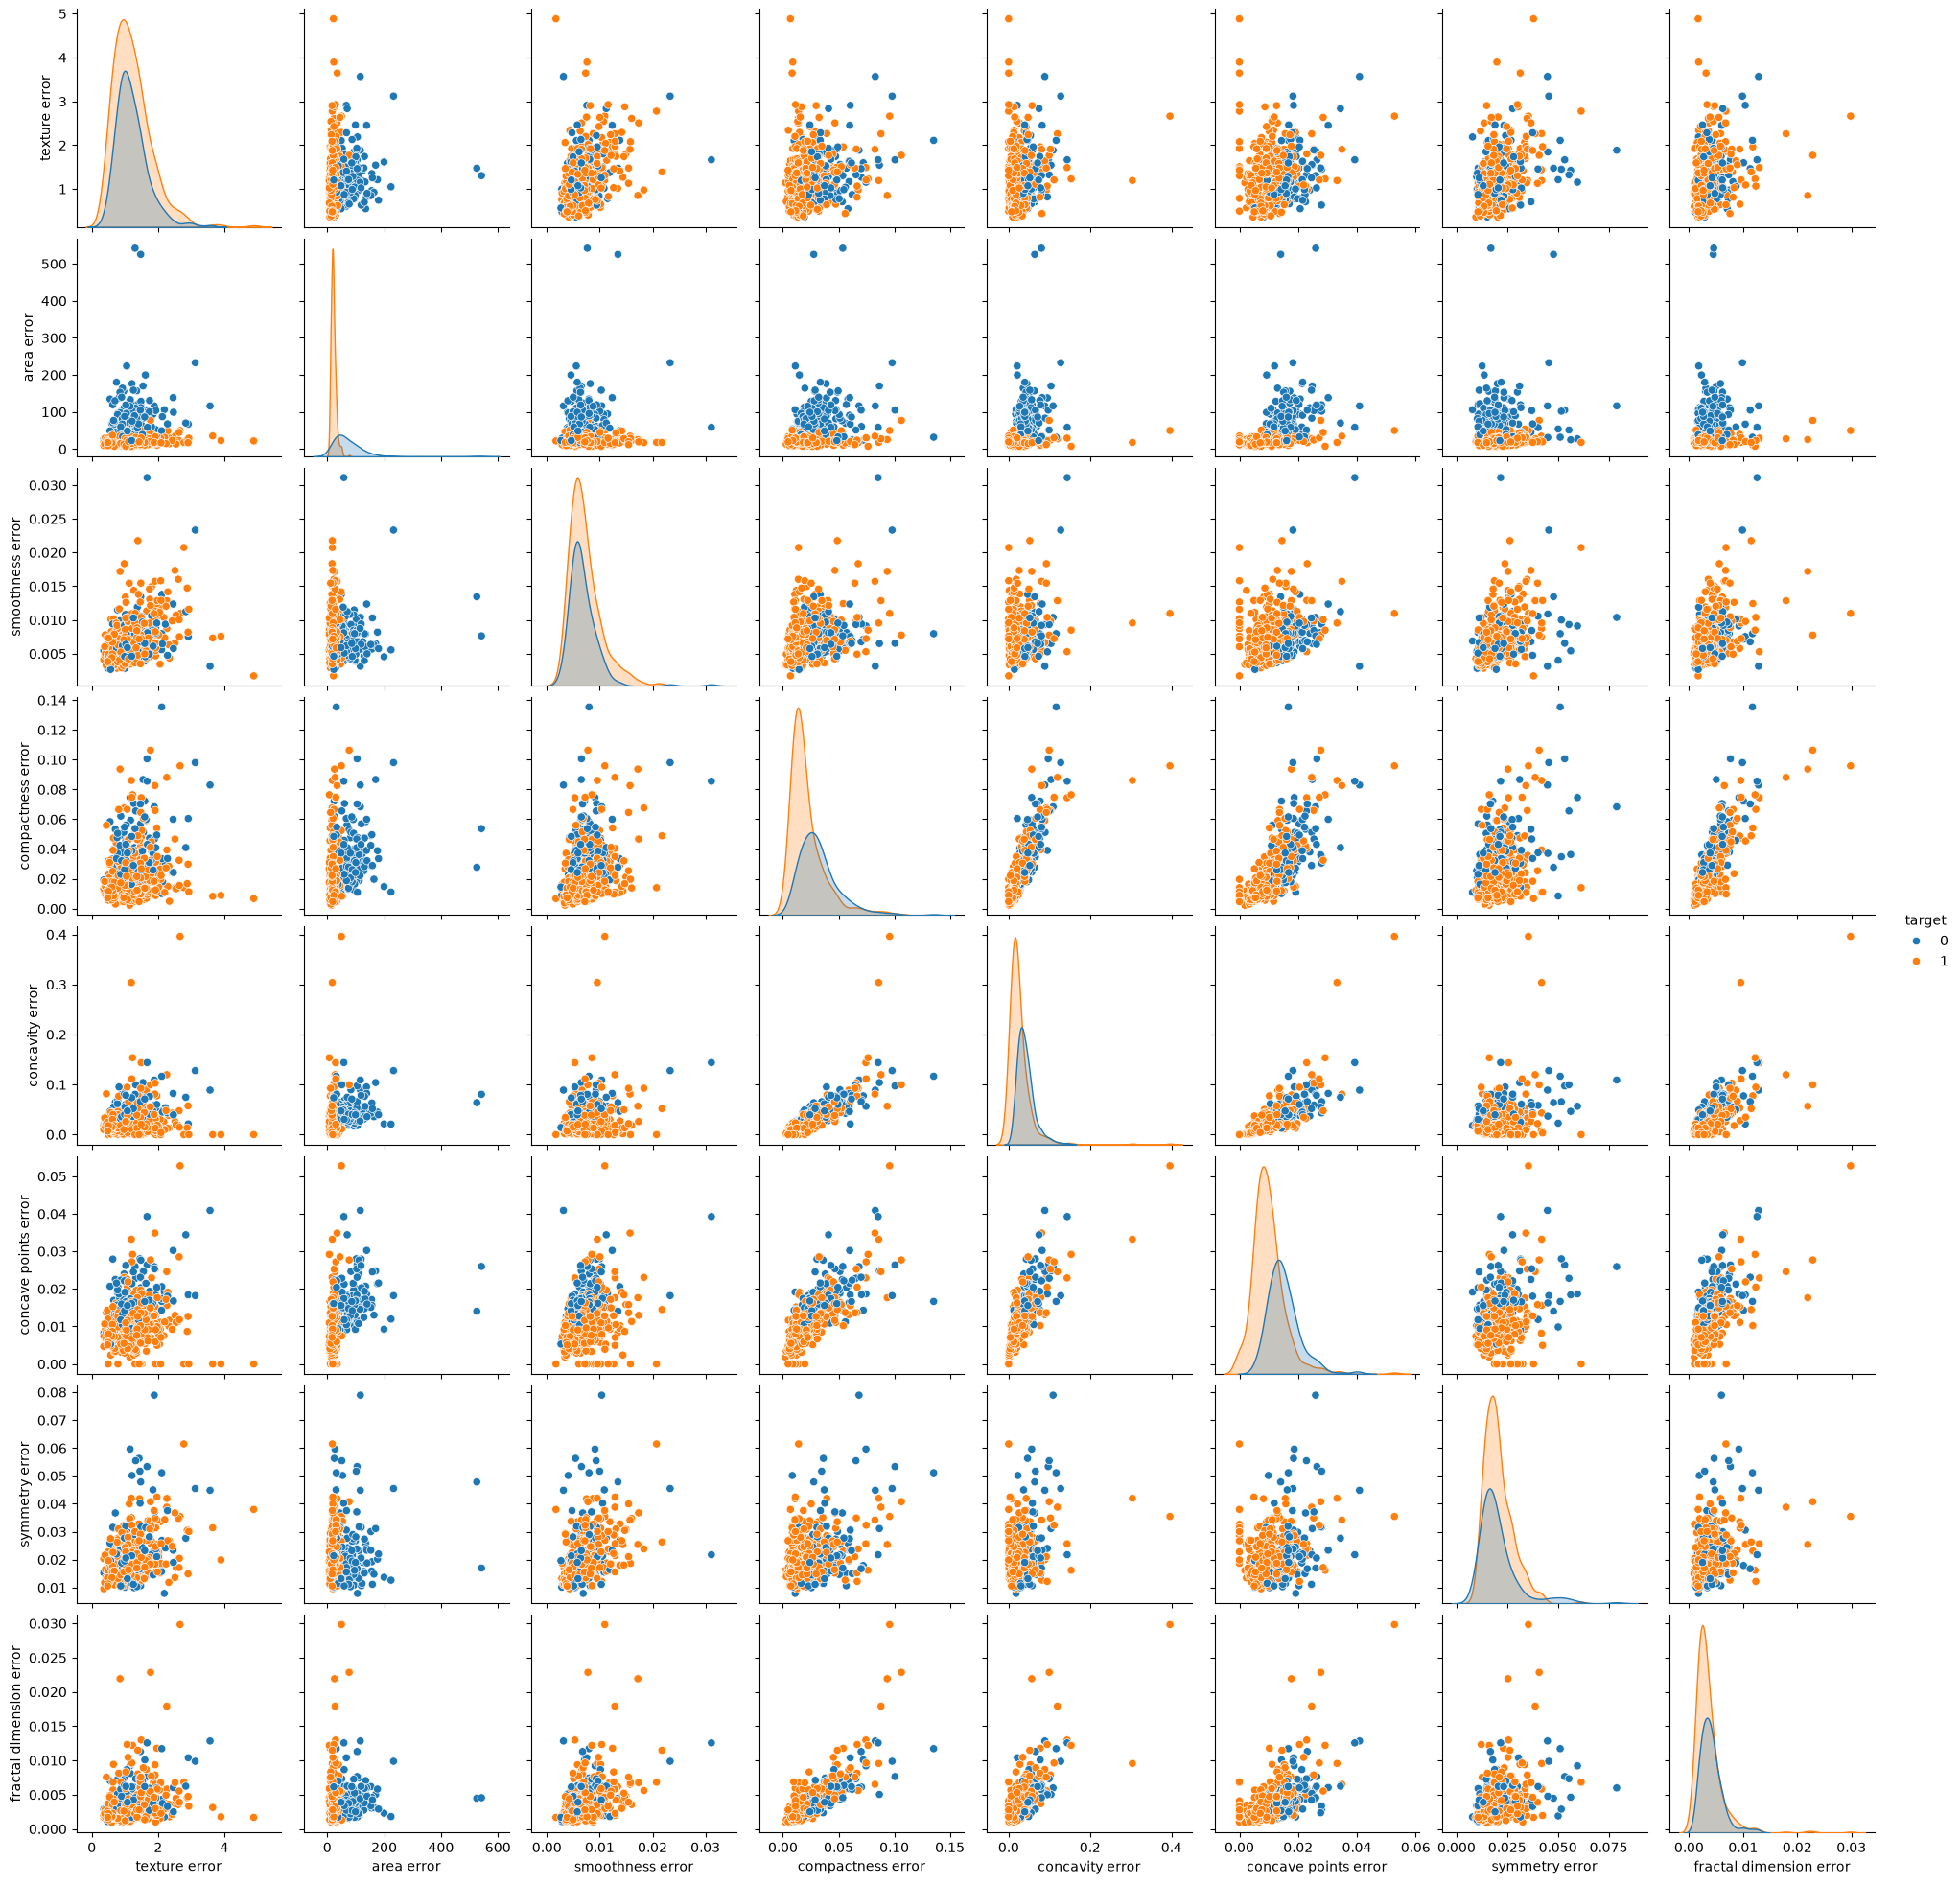

In [53]:
sns.pairplot(df_cleaned[error_features], hue='target')

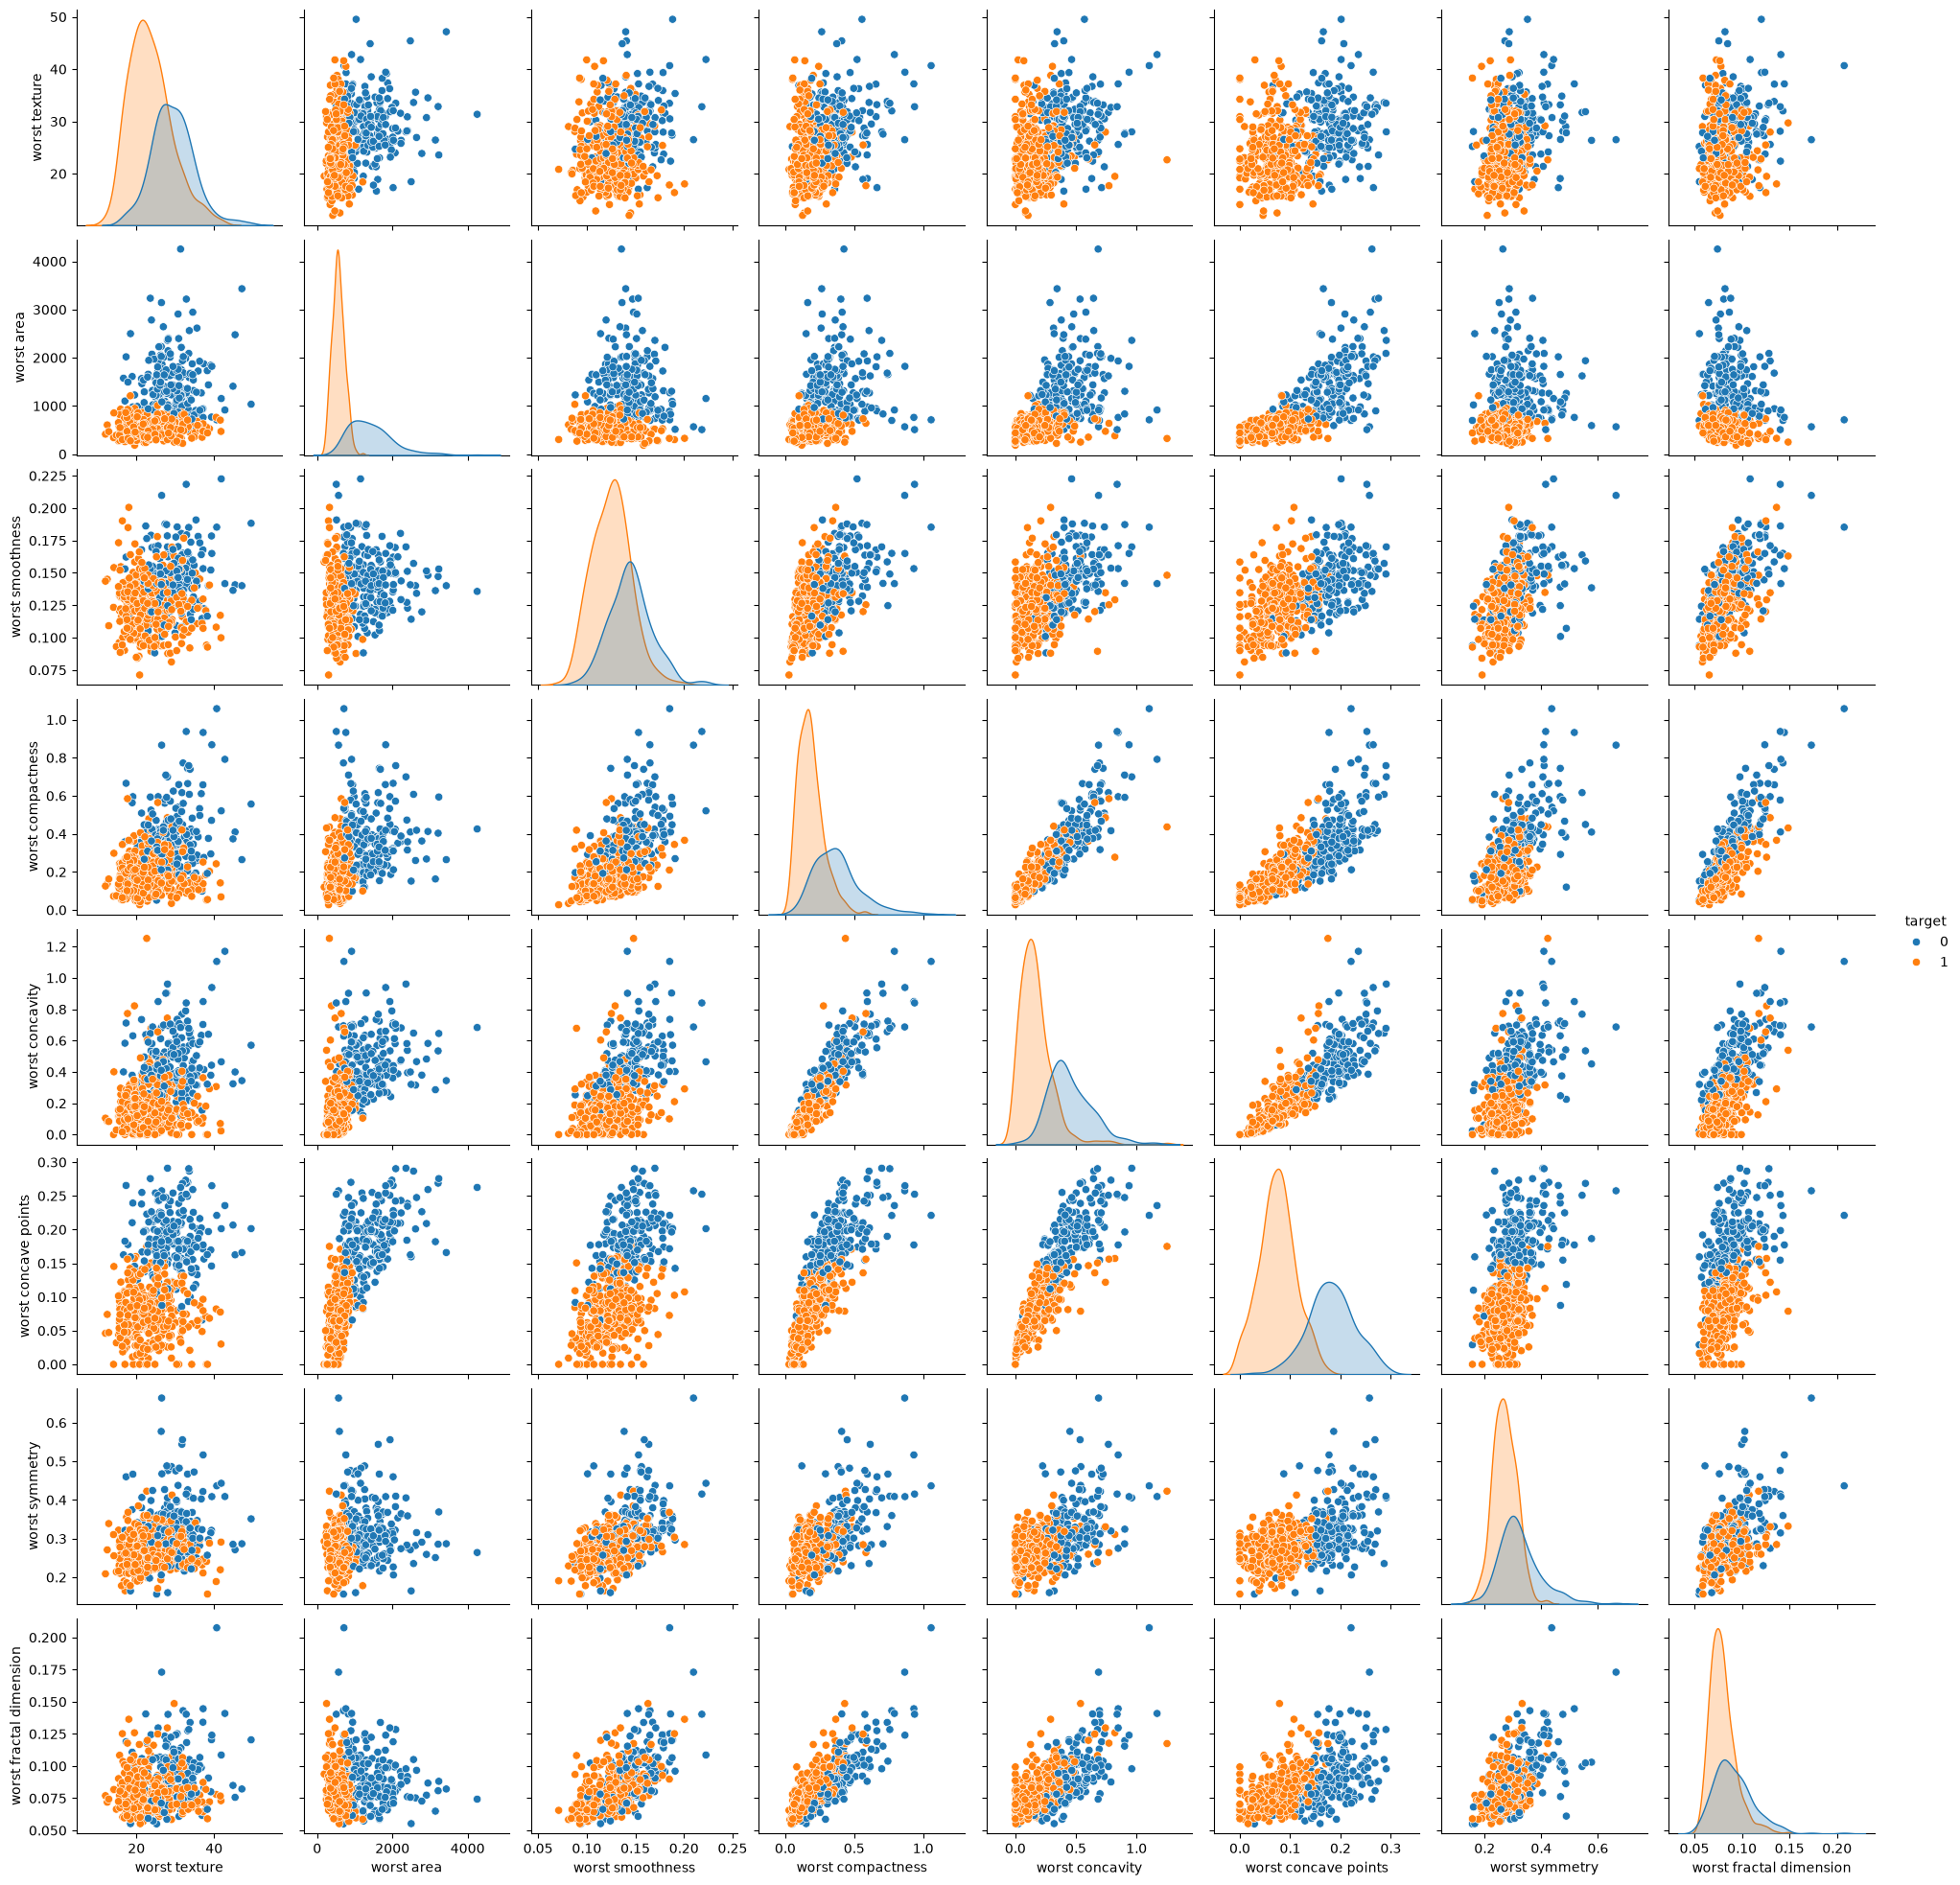

In [55]:
sns.pairplot(df_cleaned[worst_features], hue='target')

Summary:

- Dataset Scale: There are 569 total samples and 31 columns (30 features and 1 target variable)
- Data Types: The features are all continuous numeric floats representing statistical measurements of cell nuclei. The target is a categorical binary integer where 0 represents malignant and 1 represents benign
- Target Balance: The target distribution is imbalanced, containing 212 malignant (0) samples and 357 benign (1) samples
- Data Quality: There are zero missing values across the entire dataset
- Feature Structure: The 30 features are built from 10 unique physical measurements, each broken into three statistical calculations: the mean, the standard error, and the worst (mean of the three largest values)
- Multicollinearity Clean-up: The correlation heatmap revealed that the size features (radius, perimeter, and area) are highly correlated and mathematically redundant. To protect the model from multicollinearity, radius and perimeter columns were dropped, keeping only the area features (removing 6 columns total)
- Visual Insights: Pair plots across the remaining 24 features show strong linear separability between the two target classes, confirming that Logistic Regression is the correct model choice
- Handling Noise: Visual analysis also revealed that almost all error features (except area error) suffer from severe overlap with zero class separation. These 7 noisy features have been intentionally left in the dataset to allow the regularization of the Logistic Regression model to mathematically ignore them
- Final Shape: The finalised dataset enters the modeling stage with 24 features (8 measurements × 3 types) and 1 target column

## 5. Features and target

In [64]:
X = df_cleaned.drop(columns='target')
y = df_cleaned.target

## 6. Preprocessing

In [65]:
set_config(display='diagram')

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric_scaler', StandardScaler(), X.columns)
    ]
)

Scaled the numerical features so that all feature can contribute equally and not be ignored simply due to their scale

This is important for logistic regression because it uses a linear combination of the features to make predictions, and features with larger scales can dominate the model's learning process

## 7. Train/test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

We stratify on the target variable to make sure the train and test sets have the same proportion of malignant and non-malignant samples

This makes sure the data is representative of overall distribution and avoids biasing the model towards one class

## 8. Baseline model

In [ ]:
dummy_pipeline = Pipeline(
    steps=[
        ("dummy_classifier", DummyClassifier(strategy="most_frequent"))
    ]
)

dummy_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dummy_classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['mean texture','mean area','mean smoothness',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_s

In [93]:
dummy_predictions = dummy_pipeline.predict(X_test)

## 9. Logistic regression pipeline

In [ ]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("logistic_regression", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

cv_results = cross_validate(
    model_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)

print("=== Real Model 5-Fold CV Average Scores ===")
print(f"CV Accuracy:  {cv_results['test_accuracy'].mean():.4f}")
print(f"CV Precision: {cv_results['test_precision'].mean():.4f}")
print(f"CV Recall:    {cv_results['test_recall'].mean():.4f}")
print(f"CV F1 Score:  {cv_results['test_f1'].mean():.4f}")

=== Real Model 5-Fold CV Average Scores ===
CV Accuracy:  0.9714
CV Precision: 0.9694
CV Recall:    0.9861
CV F1 Score:  0.9775


## 10. Model training and predictions

In [85]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['mean texture','mean area','mean smoothness',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of `

In [92]:
model_predictions = model_pipeline.predict(X_test)

## 10. Model evaluation

In [91]:
model_accuracy = accuracy_score(y_test, model_predictions)  
model_precision = precision_score(y_test, model_predictions)
model_recall = recall_score(y_test, model_predictions)
model_f1 = f1_score(y_test, model_predictions)

matrix = confusion_matrix(y_test, model_predictions)

In [ ]:
print("=== Model Metric Evaluation ===")


## 11. Baseline comparison

In [94]:
dummy_accuracy = accuracy_score(y_test, dummy_predictions)
dummy_precision = precision_score(y_test, dummy_predictions)
dummy_recall = recall_score(y_test, dummy_predictions)
dummy_f1 = f1_score(y_test, dummy_predictions)

dummy_matrix = confusion_matrix(y_test, dummy_predictions)

## 12. Error analysis

## 13. Limitations

## 14. Conclusion